In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customer = pd.read_csv("customer_features.csv")

In [3]:
features = ['Recency', 'Frequency', 'Monetary', 'AverageBasketSize', 'CLV']
x = customer[features].fillna(0)

In [4]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [5]:
Kmeans = KMeans(n_clusters=4,random_state=42)
customer['Segment'] = Kmeans.fit_predict(x_scaled)

In [6]:
customer.groupby('Segment')[['Recency','Frequency','Monetary','CLV']].mean()


,Recency,Frequency,Monetary,CLV
Segment,,,,
0,41.373759,4.656328,1806.430211,4519.709450
1,163.500000,1.500000,122827.000000,968511.000000
2,247.026728,1.570507,503.737327,3854.825285
3,6.333333,70.708333,82003.333333,20278.563435


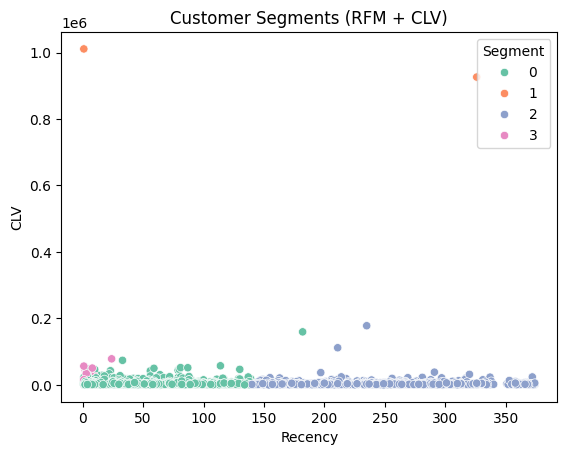

In [ ]:
sns.scatterplot(x='Recency', y='CLV', hue='Segment', data=customer, palette='Set2')
plt.title("Customer Segments (RFM + CLV)")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
X = customer[['Recency', 'Frequency', 'Monetary', 'AverageBasketSize']]
y = customer['CLV']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Random Forest CLV Prediction → MSE: {mse:.2f}, R2: {r2:.2f}")


Random Forest CLV Prediction → MSE: 7536579.59, R2: 0.79


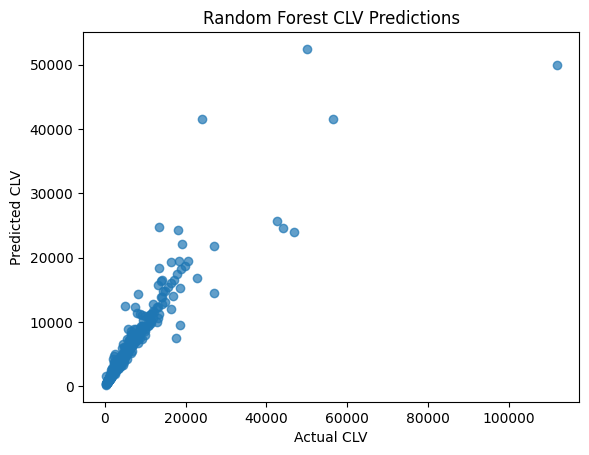

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Random Forest CLV Predictions")
plt.show()


C:\Users\ENVY\AppData\Local\Temp\ipykernel_27700\78071208.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Segment', data=customer, palette='Set2')


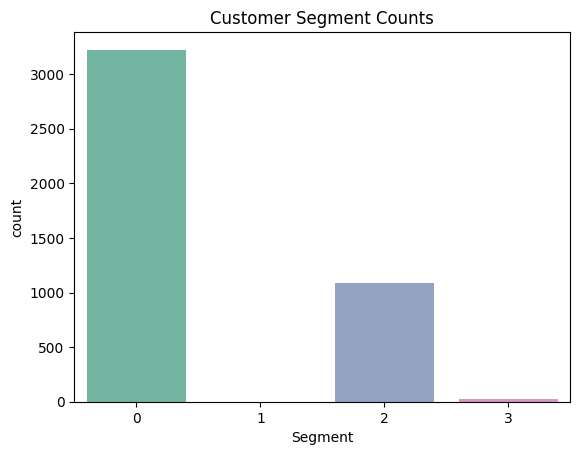

In [ ]:
sns.countplot(x='Segment', data=customer, palette='Set2')
plt.title("Customer Segment Counts")
plt.show()
